# Overview

## Background

SELENON-Congenital Myopathy (SELENON-CM) is a rare neuromuscular disease caused
by recessive mutations in the SELENON gene. It is primarily characterized by severe muscle weakness, progressive axial muscle rigidity, spinal deformities, and respiratory insufficiency that can lead to early death. It primarily affects children from as early as two years of age, but can present as late as during adulthood. SELENON encodes selenoprotein-N (SelN), which is a redox enzyme located in the endoplasmic/sarcoplasmic reticulum membrane (ER/SR). SelN has also been shown to colocalize with mitochondrial associated membranes, suggesting direct mitochondrial involvement in muscle cells. However SelN-deficient mouse and zebrafish models present with mild phenotypes, which has halted fast progression of therapeutic development and molecular mechanism discovery.

Cell painting is a high-content imaging technique that profiles cellular morphological features, and has been useful in profiling SelN-deficient cells. However, there still lacks computational tools for leveraging this data to reliably differentiate between SelN-deficient (KO) and wildtype (WT) cells. A dataset of SelN-deficient morphological features extracted from cell painting images has been provided by a colleague from the Harvard Medical
School. This project aimed to:

1. Train a feature-tokenizer transformer to classify SelN-deficient cells from wildtype cells.

2. Perform SHAP analysis to identify which morphological features are significant in the transformer model’s classification.

3. Compare the transformer’s performance against a non-deep learning model, such
as XGBoost.

## Major Findings

The XGBoost model and the FT-Transformer both were able to classify the validation split near 100% across all evaluation metrics. This strongly suggests that the morphological feature space contains a highly separable signature for SELENON deficiency. Although near perfect classification always warrants careful validation, the consistency between both model types and evaluation metrics suggest that overfitting is not an issue here.

Although both models performed comparably in terms of predictive ability, the FT-Transformer also allowed us to construct an embedding for the morphological features. This in itself is an informative and interesting step that allows us to quantitatively compare the similarities between morphological features in terms of their impact on the predictions. I'm not entirely sure yet what other useful things I can do with this embedding, but that's TBD as I learn how to work with transformers and embeddings.

Shap analysis on the FT-Transformer showed that the top 30 most significant morphological features were frequently involved with the nucleus and mitochondria, which is consistent with the biology of SELENON-CM.

## Future work

Future efforts will be spent honing in on the key morphological features that make up a phenotypic signature for SELENON-CM based on the SHAP analysis performed on the FT-Transformer.

Another worthwhile effort would be to train an image classifier directly on the cell-painting images themselves to identify visual signatures of SELENON-CM. The data used for this project was created by statistically and manually curating morphological features from cell-painting images. Perhaps an image classifier can cut down on the amount of time spent curating morphological features just to get datasets such as this one.

The ultimate goal of this work is to eventually incorporate a reliable model into a high-throughput drug screening pipeline where the model can quickly determine from morphological features if mutated muscle cells treated with specific drugs have reverted back to their healthy state. The initial work here is just the first step to achieving this goal.

---

# Dataset Preparation

The dataset was created by measuring the morphological features of both WT and KO cells across 2 different lineages in the lab, resulting in a final table stored in a `*.gct` file. The table consists of 479 morphological features (i.e. the columns) and 615 samples (i.e. the rows) total. Here, we load the data and prepare the dataset for training classifier models.

In [1]:
!pip install cmapPy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.2/150.2 kB 7.7 MB/s eta 0:00:00


**SET `local = True` FOR RUNNING LOCALLY, `local = False` FOR RUNNING ON COLAB**

In [ ]:
local = True

**SET GOOGLE DRIVE DIRECTORY WHERE YOU WILL PLACE `data.gct` IF YOU INTEND TO RUN THIS ON COLAB**

In [ ]:
gdrive_dir = "/content/drive/My Drive/enm5310-sciml/Project/"

In [ ]:
if local:
    file_path = "./data/data.gct"
else:
    from google.colab import drive
    drive.mount('/content/drive')
    file_path = gdrive_dir + "data.gct"

In [3]:
from cmapPy.pandasGEXpress.parse import parse
import pandas as pd

In [ ]:
gct = parse(file_path)
df = gct.data_df
df = df.T

/usr/local/lib/python3.12/dist-packages/cmapPy/pandasGEXpress/parse_gct.py:251: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  row_metadata = row_metadata.apply(lambda x: pd.to_numeric(x, errors="ignore"))
/usr/local/lib/python3.12/dist-packages/cmapPy/pandasGEXpress/parse_gct.py:277: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  col_metadata = col_metadata.apply(lambda x: pd.to_numeric(x, errors="ignore"))


In [5]:
df.head()

rid,Cells_AreaShape_BoundingBoxMaximum_X,Cells_AreaShape_Compactness,Cells_AreaShape_EulerNumber,Cells_AreaShape_FormFactor,Cells_AreaShape_Orientation,Cells_AreaShape_Solidity,Cells_AreaShape_Zernike_1_1,Cells_AreaShape_Zernike_2_0,Cells_AreaShape_Zernike_2_2,Cells_AreaShape_Zernike_3_1,...,Nuclei_Texture_Correlation_RNA_5_02_256,Nuclei_Texture_Correlation_RNA_5_03_256,Nuclei_Texture_DifferenceVariance_DNA_3_02_256,Nuclei_Texture_InfoMeas1_AGP_3_00_256,Nuclei_Texture_InfoMeas1_Mito_3_00_256,Nuclei_Texture_InfoMeas1_RNA_3_02_256,Nuclei_Texture_InfoMeas2_DNA_3_02_256,Nuclei_Texture_InverseDifferenceMoment_RNA_3_02_256,Nuclei_Texture_SumAverage_RNA_10_02_256,Nuclei_Texture_SumVariance_AGP_5_01_256
cid,,,,,,,,,,,,,,,,,,,,,
SAMPLE_0,2.8990,3.2422,2.2647,-3.0115,2.607400,-1.8098,-5.4476,-3.7635,-1.3939,-2.52560,...,3.18990,0.62628,0.17489,1.54390,-3.1549,-3.8900,-1.82670,1.14180,-0.22099,-1.68450
SAMPLE_1,2.7636,2.4323,1.4808,-2.4543,1.770600,-1.9241,-2.8999,-3.6214,-1.3392,-0.00173,...,0.89281,2.72740,2.06270,0.99160,-2.9119,-1.9134,-0.93317,1.30520,-1.15100,0.78428
SAMPLE_2,1.6274,3.0776,1.5580,-3.0476,0.487130,-3.7681,-4.2772,-3.0761,-1.6354,-0.53902,...,3.72420,2.90840,-0.93876,1.50790,-3.7120,-4.4216,1.02240,0.23873,0.37967,-0.90374
SAMPLE_3,2.5451,1.8246,1.4270,0.7478,0.061375,-1.0435,-3.8534,-2.8678,-1.6089,-1.49940,...,2.99990,2.40790,0.12088,0.76006,-4.0078,-3.6382,0.10520,0.59537,0.11473,0.19634
SAMPLE_4,2.1380,2.7982,1.4880,-1.1843,-1.738200,-1.7038,-3.0400,-3.6850,-1.8131,-2.85300,...,3.76320,5.24190,-1.13940,0.74999,-3.3653,-4.3669,1.34670,1.18680,-0.41040,-0.93386


In [6]:
df.describe()

rid,Cells_AreaShape_BoundingBoxMaximum_X,Cells_AreaShape_Compactness,Cells_AreaShape_EulerNumber,Cells_AreaShape_FormFactor,Cells_AreaShape_Orientation,Cells_AreaShape_Solidity,Cells_AreaShape_Zernike_1_1,Cells_AreaShape_Zernike_2_0,Cells_AreaShape_Zernike_2_2,Cells_AreaShape_Zernike_3_1,...,Nuclei_Texture_Correlation_RNA_5_02_256,Nuclei_Texture_Correlation_RNA_5_03_256,Nuclei_Texture_DifferenceVariance_DNA_3_02_256,Nuclei_Texture_InfoMeas1_AGP_3_00_256,Nuclei_Texture_InfoMeas1_Mito_3_00_256,Nuclei_Texture_InfoMeas1_RNA_3_02_256,Nuclei_Texture_InfoMeas2_DNA_3_02_256,Nuclei_Texture_InverseDifferenceMoment_RNA_3_02_256,Nuclei_Texture_SumAverage_RNA_10_02_256,Nuclei_Texture_SumVariance_AGP_5_01_256
count,615.000000,615.000000,615.000000,605.000000,615.000000,615.00000,615.000000,615.000000,615.000000,615.000000,...,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000
mean,0.103485,1.366163,0.302867,-0.595113,-0.243547,-1.35100,-0.206484,-0.504172,-0.424973,0.393973,...,0.558383,1.090539,-0.587493,-0.781617,-1.096978,-0.370865,-0.464860,-0.217755,0.222443,1.175372
std,1.407254,2.067691,0.905136,1.266820,1.380976,2.73257,1.378166,1.181536,0.929206,1.050807,...,1.348372,2.100839,1.235299,1.659769,1.396449,1.228792,1.928233,1.229218,1.244912,4.402530
min,-4.000500,-1.619000,-3.324400,-5.252700,-9.722000,-19.62800,-6.260200,-5.907800,-3.737400,-3.345400,...,-2.816400,-3.203700,-4.569200,-5.146900,-5.633300,-4.880200,-8.672700,-4.806200,-3.635900,-3.369100
25%,-0.680050,-0.033645,-0.351725,-1.360300,-1.022900,-1.91510,-0.796580,-0.944605,-1.123400,-0.375985,...,-0.431890,-0.334975,-1.365650,-1.858250,-2.125550,-1.051200,-1.145100,-0.764270,-0.607570,-0.566115
50%,0.059590,1.006300,0.258620,-0.614980,-0.175450,-0.51839,-0.042156,-0.265480,-0.365990,0.414260,...,0.427200,0.536690,-0.544640,-0.574130,-1.040700,-0.239680,-0.079261,-0.107950,0.097987,0.055549
75%,0.882485,2.155800,1.006900,0.179040,0.579960,0.29726,0.686170,0.236260,0.331620,1.113600,...,1.249300,2.106850,0.167220,0.458600,0.018298,0.538750,0.881725,0.534545,0.866575,1.162200
max,6.914800,19.889999,2.264700,3.625100,4.239300,2.24640,3.720800,1.589100,1.404600,3.615200,...,5.745300,11.305000,5.444800,6.729100,3.220600,2.885300,2.789000,3.888900,7.073400,66.195999


In [7]:
df.index

Index(['SAMPLE_0', 'SAMPLE_1', 'SAMPLE_2', 'SAMPLE_3', 'SAMPLE_4', 'SAMPLE_5',
       'SAMPLE_6', 'SAMPLE_7', 'SAMPLE_8', 'SAMPLE_9',
       ...
       'SAMPLE_605', 'SAMPLE_606', 'SAMPLE_607', 'SAMPLE_608', 'SAMPLE_609',
       'SAMPLE_610', 'SAMPLE_611', 'SAMPLE_612', 'SAMPLE_613', 'SAMPLE_614'],
      dtype='object', name='cid', length=615)

In [8]:
df.shape

(615, 479)

Inspecting the metadata for the samples shows that the WT and KO labels are in the `perturbation` column.

In [9]:
samples_metadata = gct.col_metadata_df
samples_metadata

chd,plate_map_name,control_type,perturbation,plating_density,Plate,Well,Site_Count,Count_Cells,Count_CellsIncludingEdges,Count_Cytoplasm,Count_Nuclei,Count_NucleiIncludingEdges,Object_Count,batch
cid,,,,,,,,,,,,,,
SAMPLE_0,S24_C2C12_5E5_3F9_Curve3_05162024,negcon,5E5_WT,500,S24_C2C12_5E5_3F9_Curve3_05162024,B02,9,179,194,179,179,194,179,2024_07_19_Batch1
SAMPLE_1,S24_C2C12_5E5_3F9_Curve3_05162024,negcon,5E5_WT,500,S24_C2C12_5E5_3F9_Curve3_05162024,B03,9,229,247,229,229,247,229,2024_07_19_Batch1
SAMPLE_2,S24_C2C12_5E5_3F9_Curve3_05162024,negcon,5E5_WT,500,S24_C2C12_5E5_3F9_Curve3_05162024,B04,9,254,268,254,254,268,254,2024_07_19_Batch1
SAMPLE_3,S24_C2C12_5E5_3F9_Curve3_05162024,negcon,5E5_WT,500,S24_C2C12_5E5_3F9_Curve3_05162024,B05,9,214,235,214,214,235,214,2024_07_19_Batch1
SAMPLE_4,S24_C2C12_5E5_3F9_Curve3_05162024,negcon,5E5_WT,500,S24_C2C12_5E5_3F9_Curve3_05162024,B06,9,231,250,231,231,250,231,2024_07_19_Batch1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SAMPLE_610,S24_C2C12_exon5_WT_KO_curve1,NaN,KO,3500,S24_C2C12_exon5_WT_KO_curve1,O19,9,3312,3542,3312,3312,3542,3312,2024_07_19_Batch1
SAMPLE_611,S24_C2C12_exon5_WT_KO_curve1,NaN,KO,3500,S24_C2C12_exon5_WT_KO_curve1,O20,9,2925,3132,2925,2925,3132,2925,2024_07_19_Batch1
SAMPLE_612,S24_C2C12_exon5_WT_KO_curve1,NaN,KO,3500,S24_C2C12_exon5_WT_KO_curve1,O21,9,2940,3185,2940,2940,3185,2940,2024_07_19_Batch1


In [10]:
samples_metadata["perturbation"].unique()

array(['5E5_WT', '3F9KO', 'WT', 'KO'], dtype=object)

In [11]:
samples_metadata[samples_metadata["perturbation"] == "5E5_WT"].index

Index(['SAMPLE_0', 'SAMPLE_1', 'SAMPLE_2', 'SAMPLE_3', 'SAMPLE_4', 'SAMPLE_5',
       'SAMPLE_6', 'SAMPLE_7', 'SAMPLE_8', 'SAMPLE_9',
       ...
       'SAMPLE_144', 'SAMPLE_145', 'SAMPLE_146', 'SAMPLE_147', 'SAMPLE_148',
       'SAMPLE_149', 'SAMPLE_150', 'SAMPLE_151', 'SAMPLE_152', 'SAMPLE_153'],
      dtype='object', name='cid', length=154)

In [12]:
samples_metadata[samples_metadata["perturbation"] == "3F9KO"].index

Index(['SAMPLE_154', 'SAMPLE_155', 'SAMPLE_156', 'SAMPLE_157', 'SAMPLE_158',
       'SAMPLE_159', 'SAMPLE_160', 'SAMPLE_161', 'SAMPLE_162', 'SAMPLE_163',
       ...
       'SAMPLE_297', 'SAMPLE_298', 'SAMPLE_299', 'SAMPLE_300', 'SAMPLE_301',
       'SAMPLE_302', 'SAMPLE_303', 'SAMPLE_304', 'SAMPLE_305', 'SAMPLE_306'],
      dtype='object', name='cid', length=153)

In [13]:
samples_metadata[samples_metadata["perturbation"] == "WT"].index

Index(['SAMPLE_307', 'SAMPLE_308', 'SAMPLE_309', 'SAMPLE_310', 'SAMPLE_311',
       'SAMPLE_312', 'SAMPLE_313', 'SAMPLE_314', 'SAMPLE_315', 'SAMPLE_316',
       ...
       'SAMPLE_451', 'SAMPLE_452', 'SAMPLE_453', 'SAMPLE_454', 'SAMPLE_455',
       'SAMPLE_456', 'SAMPLE_457', 'SAMPLE_458', 'SAMPLE_459', 'SAMPLE_460'],
      dtype='object', name='cid', length=154)

In [14]:
samples_metadata[samples_metadata["perturbation"] == "KO"].index

Index(['SAMPLE_461', 'SAMPLE_462', 'SAMPLE_463', 'SAMPLE_464', 'SAMPLE_465',
       'SAMPLE_466', 'SAMPLE_467', 'SAMPLE_468', 'SAMPLE_469', 'SAMPLE_470',
       ...
       'SAMPLE_605', 'SAMPLE_606', 'SAMPLE_607', 'SAMPLE_608', 'SAMPLE_609',
       'SAMPLE_610', 'SAMPLE_611', 'SAMPLE_612', 'SAMPLE_613', 'SAMPLE_614'],
      dtype='object', name='cid', length=154)

This dataset contains measurements from 2 different plates. One plate contains the `5E5WT` vs `3F9KO` cells and the other plate contains the `WT` vs `KO` cells. Although the specific knockout genes might differ, both plates are still measuring wildtype versus knockout cells. For model training, we'll assume that `5E5WT` and `3F9KO` are still equivalent to `WT` and `KO`, respectively. Let's create the labels column in our dataset from this perturbation column.

In [ ]:
# Add perturbation column to df





dfajskdlfdklfdafdafd








df.head()

rid,Cells_AreaShape_BoundingBoxMaximum_X,Cells_AreaShape_Compactness,Cells_AreaShape_EulerNumber,Cells_AreaShape_FormFactor,Cells_AreaShape_Orientation,Cells_AreaShape_Solidity,Cells_AreaShape_Zernike_1_1,Cells_AreaShape_Zernike_2_0,Cells_AreaShape_Zernike_2_2,Cells_AreaShape_Zernike_3_1,...,Nuclei_Texture_Correlation_RNA_5_03_256,Nuclei_Texture_DifferenceVariance_DNA_3_02_256,Nuclei_Texture_InfoMeas1_AGP_3_00_256,Nuclei_Texture_InfoMeas1_Mito_3_00_256,Nuclei_Texture_InfoMeas1_RNA_3_02_256,Nuclei_Texture_InfoMeas2_DNA_3_02_256,Nuclei_Texture_InverseDifferenceMoment_RNA_3_02_256,Nuclei_Texture_SumAverage_RNA_10_02_256,Nuclei_Texture_SumVariance_AGP_5_01_256,label
cid,,,,,,,,,,,,,,,,,,,,,
SAMPLE_0,2.8990,3.2422,2.2647,-3.0115,2.607400,-1.8098,-5.4476,-3.7635,-1.3939,-2.52560,...,0.62628,0.17489,1.54390,-3.1549,-3.8900,-1.82670,1.14180,-0.22099,-1.68450,0
SAMPLE_1,2.7636,2.4323,1.4808,-2.4543,1.770600,-1.9241,-2.8999,-3.6214,-1.3392,-0.00173,...,2.72740,2.06270,0.99160,-2.9119,-1.9134,-0.93317,1.30520,-1.15100,0.78428,0
SAMPLE_2,1.6274,3.0776,1.5580,-3.0476,0.487130,-3.7681,-4.2772,-3.0761,-1.6354,-0.53902,...,2.90840,-0.93876,1.50790,-3.7120,-4.4216,1.02240,0.23873,0.37967,-0.90374,0
SAMPLE_3,2.5451,1.8246,1.4270,0.7478,0.061375,-1.0435,-3.8534,-2.8678,-1.6089,-1.49940,...,2.40790,0.12088,0.76006,-4.0078,-3.6382,0.10520,0.59537,0.11473,0.19634,0
SAMPLE_4,2.1380,2.7982,1.4880,-1.1843,-1.738200,-1.7038,-3.0400,-3.6850,-1.8131,-2.85300,...,5.24190,-1.13940,0.74999,-3.3653,-4.3669,1.34670,1.18680,-0.41040,-0.93386,0


Quick check to see if there is any class imbalance in the dataset. The classes are evenly prevalent in the dataset so we don't need to worry about class imbalance.

In [16]:
# Check class imbalance
df["label"].value_counts()

,count
label,
0,308
1,307


# Model Training

## General Helper Functions and Imports

Set up device, initial imports, and helper classes/functions.

In [17]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

PyTorch version: 2.9.0+cu126
CUDA available: True
GPU: Tesla T4
Using device: cuda


In [37]:
import math
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, average_precision_score, f1_score, accuracy_score,
    confusion_matrix, roc_curve, precision_recall_curve,
)

import xgboost as xgb

In [19]:
class MorphologyDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        # X: float32 [N, D], y: int64 [N]
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [20]:
class TabularPreprocessor:
    """
    Normalize the data and handle missing values
      - median imputation
      - robust scaling (median/IQR) or standard scaling
      - optional clipping
    """
    def __init__(self, mode="robust", clip_z=None, eps=1e-8):
        assert mode in ("robust", "standard")
        self.mode = mode
        self.clip_z = clip_z
        self.eps = eps
        self.median_ = None
        self.scale_ = None  # IQR or std

    def fit(self, X: np.ndarray):
        # X: [N, D]
        self.median_ = np.nanmedian(X, axis=0)

        X_imp = np.where(np.isnan(X), self.median_, X)

        # Impute by iqr
        if self.mode == "robust":
            q1 = np.percentile(X_imp, 25, axis=0)
            q3 = np.percentile(X_imp, 75, axis=0)
            iqr = (q3 - q1)
            self.scale_ = np.where(iqr < self.eps, 1.0, iqr)
        else:
            std = X_imp.std(axis=0)
            self.scale_ = np.where(std < self.eps, 1.0, std)

        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        assert self.median_ is not None and self.scale_ is not None, "Must run TabularProcessor.fit() first"
        X_imp = np.where(np.isnan(X), self.median_, X)

        if self.mode == "robust":
            X_scaled = (X_imp - self.median_) / self.scale_
        else:
            mean = X_imp.mean(axis=0)  # NOTE: if you want strict train-only mean, store it too.
            X_scaled = (X_imp - mean) / self.scale_

        if self.clip_z is not None:
            X_scaled = np.clip(X_scaled, -self.clip_z, self.clip_z)

        return X_scaled.astype(np.float32)


## XGBoost

We first trained a baseline XGBoost (XGBClassifier) model for binary classification of the samples (WT vs. KO). The model was configured with up to 3000 boosting rounds and a small learning rate of 0.02, relying on early stopping during training to select the effective number of trees. Each tree was constrained to maximum depth 4 to limit model complexity and reduce overfitting. To further regularize the ensemble, we used row subsampling (`subsample = 0.8`) and feature subsampling per tree (`colsample_bytree = 0.8`), so each tree was fit on a random subset of samples and features. Standard L2 regularization (`reg_lambda = 1.0`) was applied to leaf weights (with no L1 penalty, `reg_alpha = 0.0`). Performance was monitored using log loss, ROC-AUC, and PR-AUC on the validation set.

### Model setup and training

In [21]:
label_col = "label"
feature_cols = [c for c in df.columns if c != label_col]

In [22]:
X = df[feature_cols].to_numpy(dtype=np.float32)
y = df[label_col].to_numpy(dtype=np.int64)

In [23]:
X_tr, X_va, y_tr, y_va = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [24]:
prep = TabularPreprocessor(mode="robust", clip_z=5.0)
prep.fit(X_tr)
X_tr_p = prep.transform(X_tr)
X_va_p = prep.transform(X_va)

In [25]:
clf = xgb.XGBClassifier(
    n_estimators=3000,
    learning_rate=0.02,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    min_child_weight=1.0,
    gamma=0.0,
    objective="binary:logistic",
    eval_metric=["logloss", "auc", "aucpr"],
    tree_method="hist", # for CPU
    # tree_method="gpu_hist", # for GPU
    #scale_pos_weight=scale_pos_weight,
    random_state=42,
)

In [26]:
clf.fit(
    X_tr_p, y_tr,
    eval_set=[(X_va_p, y_va)],
    verbose=True,
)

[0]	validation_0-logloss:0.67720	validation_0-auc:0.95743	validation_0-aucpr:0.94635
[1]	validation_0-logloss:0.66125	validation_0-auc:0.97197	validation_0-aucpr:0.97991
[2]	validation_0-logloss:0.64509	validation_0-auc:0.98255	validation_0-aucpr:0.98687
[3]	validation_0-logloss:0.63032	validation_0-auc:0.98678	validation_0-aucpr:0.99091
[4]	validation_0-logloss:0.61497	validation_0-auc:0.99458	validation_0-aucpr:0.99518
[5]	validation_0-logloss:0.60057	validation_0-auc:0.99484	validation_0-aucpr:0.99557
[6]	validation_0-logloss:0.58749	validation_0-auc:0.99788	validation_0-aucpr:0.99792
[7]	validation_0-logloss:0.57434	validation_0-auc:0.99841	validation_0-aucpr:0.99842
[8]	validation_0-logloss:0.56087	validation_0-auc:0.99894	validation_0-aucpr:0.99895
[9]	validation_0-logloss:0.54772	validation_0-auc:0.99947	validation_0-aucpr:0.99948
[10]	validation_0-logloss:0.53513	validation_0-auc:0.99974	validation_0-aucpr:0.99973
[11]	validation_0-logloss:0.52297	validation_0-auc:0.99974	valid

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=['logloss', 'auc', 'aucpr'],
              feature_types=None, feature_weights=None, gamma=0.0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.02, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=1.0, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=3000, n_jobs=None,
              num_parallel_tree=None, ...)

In [27]:
# predict
probs = clf.predict_proba(X_va_p)[:, 1]
pred_05 = (probs >= 0.5).astype(int)

In [32]:
metrics = {
    "roc_auc": roc_auc_score(y_va, probs) if len(np.unique(y_va)) == 2 else np.nan,
    "pr_auc": average_precision_score(y_va, probs) if len(np.unique(y_va)) == 2 else np.nan,
    "acc@0.5": accuracy_score(y_va, pred_05),
    "f1@0.5": f1_score(y_va, pred_05, zero_division=0),
    "prec@0.5": precision_score(y_va, pred_05, zero_division=0),
    "rec@0.5": recall_score(y_va, pred_05, zero_division=0),
    "best_iteration": getattr(clf, "best_iteration", None),
}

### Model Performance

The XGBoost model achieved perfect classification performance across all evaluated metrics. The model perfectly separated wildtype and SELENON-deficient samples in the validation split, with no false positives or false negatives at the default decision threshold of 0.5.

In [33]:
print("XGBoost validation metrics:")
for k, v in metrics.items():
    print(f"  {k}: {v}")

XGBoost validation metrics:
  roc_auc: 1.0
  pr_auc: 1.0
  acc@0.5: 1.0
  f1@0.5: 1.0
  prec@0.5: 1.0
  rec@0.5: 1.0
  best_iteration: None


<Figure size 640x480 with 0 Axes>

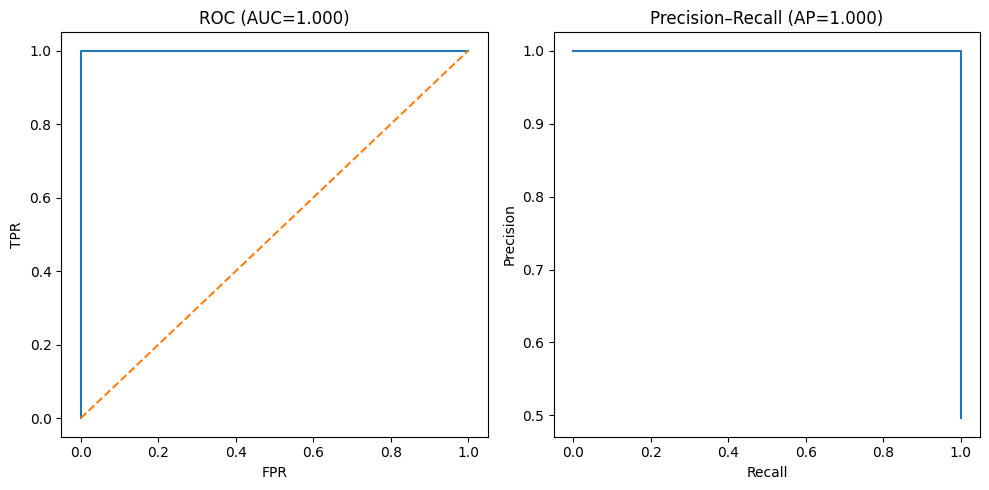

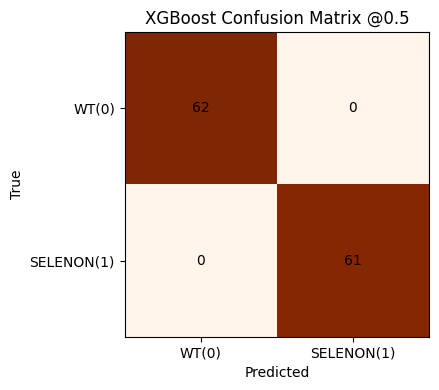

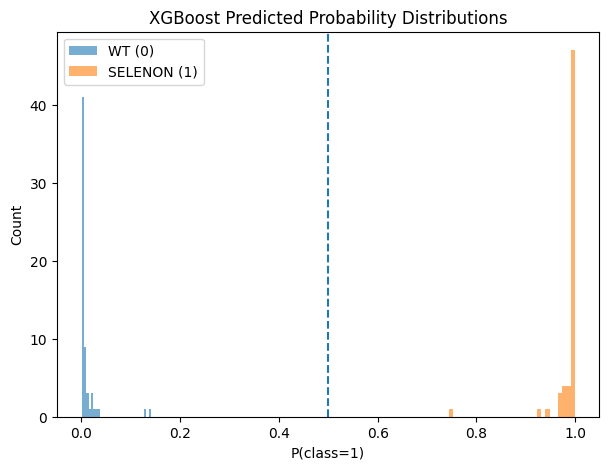

In [38]:
plt.clf()
xgb_roc_pr_fig = plt.figure(figsize=(10,5))

# ROC
fpr, tpr, _ = roc_curve(y_va, probs)
roc_ax = xgb_roc_pr_fig.add_subplot(1,2,1)
roc_ax.plot(fpr, tpr)
roc_ax.plot([0,1],[0,1], linestyle="--")
roc_ax.set_xlabel("FPR")
roc_ax.set_ylabel("TPR")
roc_ax.set_title(f"ROC (AUC={metrics['roc_auc']:.3f})")

# PR
prec, rec, _ = precision_recall_curve(y_va, probs)
pr_ax = xgb_roc_pr_fig.add_subplot(1,2,2)
pr_ax.plot(rec, prec)
pr_ax.set_xlabel("Recall")
pr_ax.set_ylabel("Precision")
pr_ax.set_title(f"Precision–Recall (AP={metrics['pr_auc']:.3f})")

xgb_roc_pr_fig.tight_layout()

# Confusion Matrix @0.5
cm = confusion_matrix(y_va, pred_05)
plt.figure(figsize=(5,4))
plt.imshow(cm, interpolation="nearest", cmap="Oranges")
plt.title("XGBoost Confusion Matrix @0.5")
plt.xticks([0,1], ["WT(0)", "SELENON(1)"])
plt.yticks([0,1], ["WT(0)", "SELENON(1)"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i,j]), ha="center", va="center")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout()

# Probability histograms
plt.figure(figsize=(7,5))
plt.hist(probs[y_va==0], bins=30, alpha=0.6, label="WT (0)")
plt.hist(probs[y_va==1], bins=30, alpha=0.6, label="SELENON (1)")
plt.axvline(0.5, linestyle="--")
plt.title("XGBoost Predicted Probability Distributions")
plt.xlabel("P(class=KO)")
plt.ylabel("Count")
plt.legend()

## Feature-Tokenizer Transformer

Here, we implemented a feature-tokenizer Transformer for tabular data. Each morphological feature is treated as a token. For each sample, each feature is combined with its value then mapped into a learned embedding space.

For example, suppose we are trying to create a 4-dimensional embedding (`d_model = 4`), and there are 3 morphological features (`D = 3`): Area, Perimeter, Texture. Given a sample `x = [0.7, -1.2, 0.1]`, the tokenizer then creates:
- `token_0 = feature_identity(area) + (0.7*w_area + b_area)`
- `token_1 = feature_identity(perim) + (-1.2*w_perim + b_perim)`
- `token_2 = feature_identity(texture) + (0.1*w_texture + b_texture)`

A learnable [CLS] token is prepended to the resulting sequence of feature tokens, and a multi-layer Transformer encoder with multi-head self-attention is applied to model interactions among features. The final [CLS] embedding serves as a global representation of each sample and is passed through a small multilayer perceptron to produce a binary classification logit. This architecture enables the model to capture nonlinear relationships between morphological features.

### Model setup and training

In [70]:
class FeatureTokenizer(nn.Module):
    """
    Turns morphological features into tokens.

    token_j = feature_id_embed[j] + (x_j * w_j + b_j)

    Implemented efficiently as:
      - id embedding: nn.Embedding(D, d_model)
      - value projection: w, b as nn.Parameter of shape [D, d_model]
    """
    def __init__(self, num_features: int, d_model: int):
        super().__init__()
        self.num_features = num_features
        self.d_model = d_model

        self.feature_embed = nn.Embedding(num_features, d_model)
        self.w = nn.Parameter(torch.randn(num_features, d_model) * 0.02)
        self.b = nn.Parameter(torch.zeros(num_features, d_model))

        # precompute indices [0..D-1] so we don't have to recreate every call
        self.register_buffer("feat_idx", torch.arange(num_features, dtype=torch.long))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: [B, D] float
        returns: [B, D, d_model]
        """
        B, D = x.shape
        assert D == self.num_features

        # feature identity embedding
        # [D, d_model] -> [1, D, d_model] -> [B, D, d_model]
        e = self.feature_embed(self.feat_idx).unsqueeze(0).expand(B, -1, -1)

        # value embedding: x_j * w_j + b_j
        # x: [B, D] -> [B, D, 1]
        x_ = x.unsqueeze(-1)
        val = x_ * self.w.unsqueeze(0) + self.b.unsqueeze(0)  # [B, D, d_model]

        return e + val

In [71]:
class TabTransformerClassifier(nn.Module):
    def __init__(
        self,
        num_features: int,
        d_model: int = 128,
        n_heads: int = 8,
        n_layers: int = 3,
        dropout: float = 0.2,
        token_dropout: float = 0.1, # randomly mask features at train time
        mlp_hidden: int = 128,
    ):
        super().__init__()
        self.num_features = num_features
        self.d_model = d_model
        self.token_dropout = token_dropout

        self.tokenizer = FeatureTokenizer(num_features, d_model)

        # CLS token
        self.cls = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.normal_(self.cls, std=0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=4*d_model,
            dropout=dropout,
            activation="gelu",
            batch_first=True, # important: expects [B, T, d]
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        self.norm = nn.LayerNorm(d_model)

        self.head = nn.Sequential(
            nn.Linear(d_model, mlp_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, 1), # logits for binary classification
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: [B, D]
        returns logits: [B]
        """
        B, D = x.shape

        # Feature/token dropout: mask some feature values to 0 (after scaling)
        if self.training and self.token_dropout > 0:
            mask = (torch.rand(B, D, device=x.device) > self.token_dropout).float()
            x = x * mask

        tok = self.tokenizer(x) # [B, D, d_model]

        cls = self.cls.expand(B, -1, -1) # [B, 1, d_model]
        seq = torch.cat([cls, tok], dim=1) # [B, 1+D, d_model]

        h = self.encoder(seq) # [B, 1+D, d_model]
        h_cls = self.norm(h[:, 0, :]) # [B, d_model]

        logits = self.head(h_cls).squeeze(-1) # [B]
        return logits

In [72]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    all_predicted = []
    all_y = []
    for X, y in loader:
        X = X.to(device)
        y = y.to(device)
        predicted = model(X)
        all_predicted.append(predicted.detach().cpu())
        all_y.append(y.detach().cpu())

    predicted = torch.cat(all_predicted).numpy()
    y_true = torch.cat(all_y).numpy()

    probs = 1.0 / (1.0 + np.exp(-predicted))  # sigmoid
    y_pred = (probs >= 0.5).astype(np.int64)

    # Metrics (guard against edge cases with single-class batches)
    out = {}
    try:
        out["roc_auc"] = roc_auc_score(y_true, probs)
    except ValueError:
        out["roc_auc"] = float("nan")

    try:
        out["pr_auc"] = average_precision_score(y_true, probs)
    except ValueError:
        out["pr_auc"] = float("nan")

    out["f1"] = f1_score(y_true, y_pred, zero_division=0)
    out["acc"] = accuracy_score(y_true, y_pred)
    return out

In [73]:
def train_one_run(
    X_train, y_train,
    X_val, y_val,
    *,
    d_model=128,
    n_heads=8,
    n_layers=3,
    dropout=0.2,
    token_dropout=0.1,
    batch_size=64,
    lr=2e-4,
    weight_decay=1e-3,
    max_epochs=200,
    patience=20,
    pos_weight=None,   # torch scalar or None
    device=None
):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    train_ds = MorphologyDataset(X_train, y_train)
    val_ds = MorphologyDataset(X_val, y_val)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=True)

    model = TabTransformerClassifier(
        num_features=X_train.shape[1],
        d_model=d_model,
        n_heads=n_heads,
        n_layers=n_layers,
        dropout=dropout,
        token_dropout=token_dropout,
        mlp_hidden=d_model,
    ).to(device)

    # Loss
    if pos_weight is not None:
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
    else:
        criterion = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Simple cosine schedule (optional)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)

    best = {"model": None, "score": -np.inf, "epoch": -1}
    bad_epochs = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        for Xb, yb in train_loader:
            Xb = Xb.to(device)
            yb = yb.to(device).float()

            logits = model(Xb)
            loss = criterion(logits, yb)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        scheduler.step()

        metrics = evaluate(model, val_loader, device)
        # early-stop metric roc-auc
        score = metrics["roc_auc"]
        if np.isnan(score):
            # fallback if roc-auc can't be computed
            score = metrics["pr_auc"]

        if score > best["score"]:
            best["score"] = score
            best["epoch"] = epoch
            best["model"] = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            break

    # Load best
    if best["model"] is not None:
        model.load_state_dict(best["model"])

    final_metrics = evaluate(model, val_loader, device)
    return model, final_metrics, best

In [74]:
def run_train_val_split(
    df: pd.DataFrame,
    feature_cols,
    label_col: str,
    test_size: float = 0.2,
    random_state: int = 42,
):
    X = df[feature_cols].to_numpy(dtype=np.float32)
    y = df[label_col].to_numpy(dtype=np.int64)

    X_tr, X_va, y_tr, y_va = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )

    # Preprocess (fit on train only)
    prep = TabularPreprocessor(mode="robust", clip_z=5.0)
    prep.fit(X_tr)
    X_tr = prep.transform(X_tr)
    X_va = prep.transform(X_va)

    # Handle class imbalance via pos_weight if needed
    # pos_weight = (#neg / #pos)
    n_pos = (y_tr == 1).sum()
    n_neg = (y_tr == 0).sum()
    pos_weight = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float32)

    model, val_metrics, best = train_one_run(
        X_tr, y_tr,
        X_va, y_va,
        d_model=128,
        n_heads=8,
        n_layers=3,
        dropout=0.2,
        token_dropout=0.1,
        batch_size=64,
        lr=2e-4,
        weight_decay=1e-3,
        max_epochs=300,
        patience=30,
        pos_weight=pos_weight,
    )

    print("Best epoch:", best["epoch"])
    print("Validation metrics:", val_metrics)
    return model, prep, X_tr, X_va, y_tr, y_va

In [75]:
# @title
# Created this function with the intention of running 5-fold cross-validation in the future
# Not currently used in this notebook
def run_5fold_cv(
    df: pd.DataFrame,
    feature_cols,
    label_col: str,
    n_splits: int = 5,
    random_state: int = 42,
):
    X_all = df[feature_cols].to_numpy(dtype=np.float32)
    y_all = df[label_col].to_numpy(dtype=np.int64)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    fold_metrics = []
    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_all, y_all), start=1):
        X_tr_raw, y_tr = X_all[tr_idx], y_all[tr_idx]
        X_va_raw, y_va = X_all[va_idx], y_all[va_idx]

        prep = TabularPreprocessor(mode="robust", clip_z=5.0)
        prep.fit(X_tr_raw)
        X_tr = prep.transform(X_tr_raw)
        X_va = prep.transform(X_va_raw)

        n_pos = (y_tr == 1).sum()
        n_neg = (y_tr == 0).sum()
        pos_weight = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float32)

        _, metrics, best = train_one_run(
            X_tr, y_tr,
            X_va, y_va,
            d_model=128,
            n_heads=8,
            n_layers=3,
            dropout=0.2,
            token_dropout=0.1,
            batch_size=64,
            lr=2e-4,
            weight_decay=1e-3,
            max_epochs=300,
            patience=30,
            pos_weight=pos_weight,
        )

        print(f"\nFold {fold}: best_epoch={best['epoch']} metrics={metrics}")
        fold_metrics.append(metrics)

    # Aggregate
    def mean_std(key):
        vals = np.array([m[key] for m in fold_metrics], dtype=np.float32)
        return float(np.nanmean(vals)), float(np.nanstd(vals))

    summary = {k: mean_std(k) for k in fold_metrics[0].keys()}
    print("\n=== CV Summary (mean ± std) ===")
    for k, (mu, sd) in summary.items():
        print(f"{k}: {mu:.4f} ± {sd:.4f}")

    return fold_metrics, summary

Run the training

In [76]:
label_col = "label"  # 0/1
feature_cols = [c for c in df.columns if c != label_col]
model, prep, X_tr, X_va, y_tr, y_va = run_train_val_split(df, feature_cols, label_col)

# fold_metrics, summary = run_5fold_cv(df, feature_cols, label_col)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Best epoch: 24
Validation metrics: {'roc_auc': np.float64(1.0), 'pr_auc': np.float64(1.0), 'f1': 1.0, 'acc': 1.0}


### Model performance

Similar to the XGBoost model, the FT-Transformer also achieved near perfect classification across all evaluation metrics.

In [77]:
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
)
from sklearn.calibration import calibration_curve
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [78]:
@torch.no_grad()
def collect_probs_and_labels(model, loader, device):
    model.eval()
    probs_list, y_list = [], []
    for X, y in loader:
        X = X.to(device)
        prediction = model(X)
        probs = torch.sigmoid(prediction).detach().cpu().numpy()
        probs_list.append(probs)
        y_list.append(y.detach().cpu().numpy())
    probs = np.concatenate(probs_list)
    y = np.concatenate(y_list).astype(int)
    return probs, y

In [79]:
def best_f1_threshold(y_true, probs):
    # sweep thresholds to maximize F1
    thresholds = np.linspace(0.0, 1.0, 501)
    best_t, best_f = 0.5, -1.0
    for t in thresholds:
        y_pred = (probs >= t).astype(int)
        f = f1_score(y_true, y_pred, zero_division=0)
        if f > best_f:
            best_f, best_t = f, t
    return best_t, best_f

In [99]:
def plot_model_performance(y_true, probs, title_prefix="Validation"):
    # Basic headline metrics
    roc_auc = roc_auc_score(y_true, probs) if len(np.unique(y_true)) == 2 else np.nan
    pr_auc = average_precision_score(y_true, probs) if len(np.unique(y_true)) == 2 else np.nan

    # Curves
    fpr, tpr, _ = roc_curve(y_true, probs)
    prec, rec, pr_thresh = precision_recall_curve(y_true, probs)

    # Thresholds
    #t_best, f1_best = best_f1_threshold(y_true, probs)

    def summarize_at_threshold(t):
        y_pred = (probs >= t).astype(int)
        return {
            "threshold": t,
            "acc": accuracy_score(y_true, y_pred),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "cm": confusion_matrix(y_true, y_pred),
        }

    s_05 = summarize_at_threshold(0.5)
    #s_best = summarize_at_threshold(t_best)

    print(f"{title_prefix} ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f}")
    print(f"@0.50:  acc={s_05['acc']:.4f} f1={s_05['f1']:.4f} prec={s_05['precision']:.4f} rec={s_05['recall']:.4f}")
    #print(f"@bestF1(thr={t_best:.3f}): acc={s_best['acc']:.4f} f1={s_best['f1']:.4f} prec={s_best['precision']:.4f} rec={s_best['recall']:.4f}")

    # Plot ROC curve and PR curve next to each other
    # ROC Curve
    fig1 = plt.figure(figsize=(10, 5))
    ax1 = fig1.add_subplot(1, 2, 1)
    ax1.plot(fpr, tpr)
    ax1.plot([0, 1], [0, 1], linestyle="--")
    ax1.set_xlabel("False Positive Rate")
    ax1.set_ylabel("True Positive Rate")
    ax1.set_title(f"ROC Curve (AUC={roc_auc:.3f})")

    # Precision-Recall Curve
    ax2 = fig1.add_subplot(1, 2, 2)
    ax2.plot(rec, prec)
    ax2.set_xlabel("Recall")
    ax2.set_ylabel("Precision")
    ax2.set_title(f"Precision–Recall (AP={pr_auc:.3f})")

    fig1.tight_layout()

    # Confusion Matrices
    def plot_cm(ax: plt.Axes, cm, cm_title):
        ax.imshow(cm, interpolation="nearest", cmap="Oranges")
        ax.set_title(cm_title)
        tick_marks = np.arange(2)
        ax.set_xticks(tick_marks, ["WT(0)", "SELENON(1)"])
        ax.set_yticks(tick_marks, ["WT(0)", "SELENON(1)"])
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")

        # annotate
        for i in range(2):
            for j in range(2):
                ax.text(j, i, str(cm[i, j]), ha="center", va="center")

    # Plot confusion matrices next to each other
    fig2 = plt.figure(figsize=(10, 5))
    ax3 = fig2.add_subplot(1, 2, 1)

    plot_cm(ax3, s_05["cm"], f"{title_prefix} Confusion Matrix @0.50")
    #plot_cm(ax4, s_best["cm"], f"{title_prefix} Confusion Matrix @bestF1 (thr={t_best:.3f})")

    # Probability histograms by class
    probs0 = probs[y_true == 0]
    probs1 = probs[y_true == 1]

    plt.figure(figsize=(7, 5))
    plt.hist(probs0, bins=30, alpha=0.6, label="WT (0)")
    plt.hist(probs1, bins=30, alpha=0.6, label="SELENON (1)")
    plt.axvline(0.5, linestyle="--")
    #plt.axvline(t_best, linestyle="--")
    plt.xlabel("P(class=1)")
    plt.ylabel("Count")
    plt.title(f"FT-Transformer Predicted Probability Distributions")
    plt.legend()
    plt.show()

    # Calibration curve (reliability diagram)
    frac_pos, mean_pred = calibration_curve(y_true, probs, n_bins=10, strategy="uniform")

    plt.figure(figsize=(6, 5))
    plt.plot(mean_pred, frac_pos, marker="o")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.title(f"{title_prefix} Calibration Curve")
    plt.show()

    # Threshold sweep (F1/precision/recall vs threshold)
    thresholds = np.linspace(0, 1, 201)
    f1s, precs, recs = [], [], []
    for t in thresholds:
        y_pred = (probs >= t).astype(int)
        f1s.append(f1_score(y_true, y_pred, zero_division=0))
        precs.append(precision_score(y_true, y_pred, zero_division=0))
        recs.append(recall_score(y_true, y_pred, zero_division=0))

    plt.figure(figsize=(7, 5))
    plt.plot(thresholds, f1s, label="F1")
    plt.plot(thresholds, precs, label="Precision")
    plt.plot(thresholds, recs, label="Recall")
    plt.axvline(0.5, linestyle="--", label="0.5")
    #plt.axvline(t_best, linestyle="--", label=f"bestF1={t_best:.3f}")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title(f"{title_prefix} Threshold Sweep")
    plt.legend()
    plt.show()

Validation ROC-AUC: 1.0000 | PR-AUC: 1.0000
@0.50:  acc=1.0000 f1=1.0000 prec=1.0000 rec=1.0000


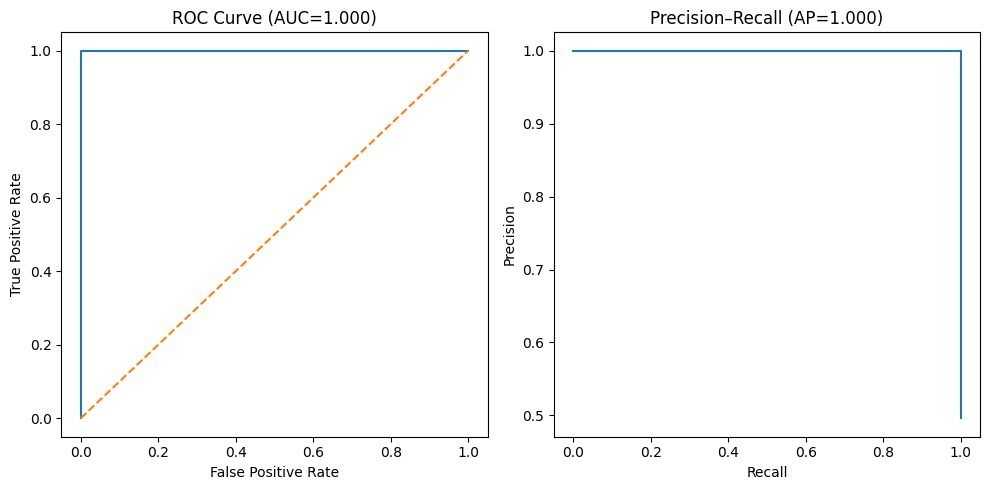

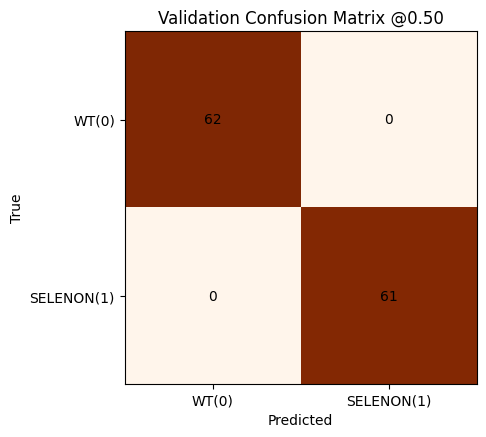

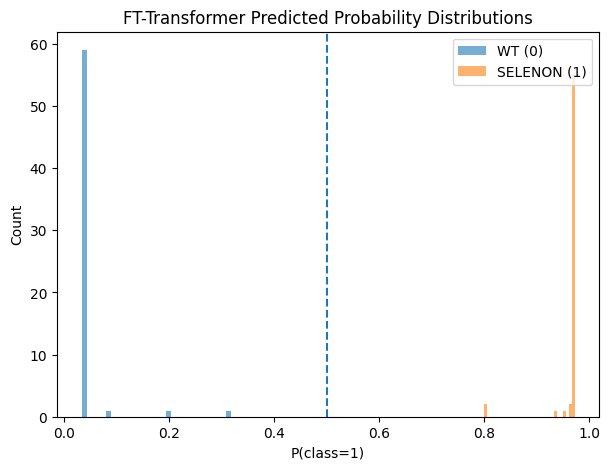

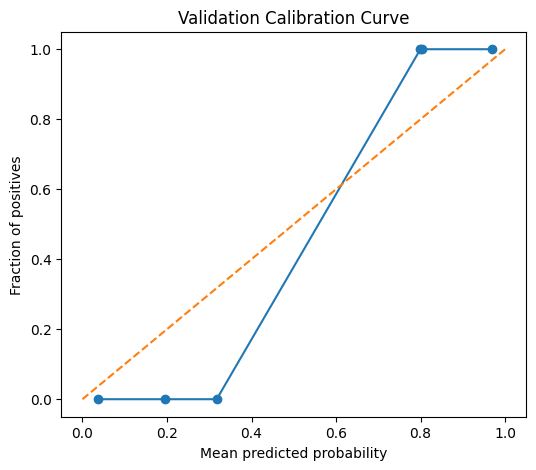

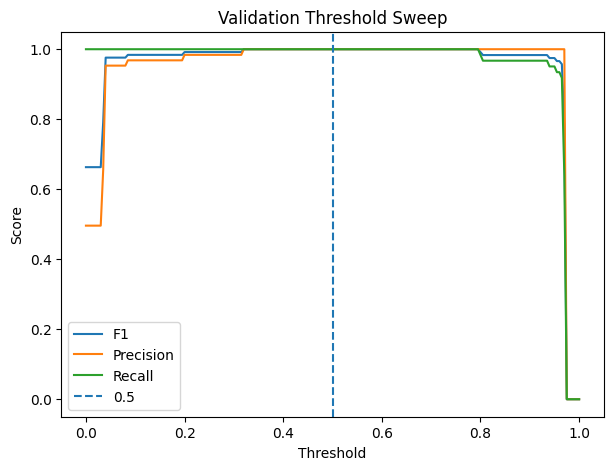

In [100]:
ds = MorphologyDataset(X_va, y_va)
val_loader = DataLoader(ds, batch_size=256, shuffle=False)
probs_val, y_val = collect_probs_and_labels(model, val_loader, device)
plot_model_performance(y_val, probs_val, title_prefix="Validation")

### SHAP Analysis

We were interested in identifying which morphological features were contributing the most to the FT-Tokenizer Transformer's prediction. Shap analysis was applied to the model and the results are shown below.

The top 30 most significant morphological features were frequently involved with the nucleus and mitochondria. This is consistent with the biology of SELEON-CM. When the SELENON gene is mutated, Selenoprotein-N production is disrupted and can no longer colocalize in the endoplasmic reticulum and the mitochondrial membranes thereby affecting their physical characteristics.

In [101]:
import numpy as np
import torch
import shap

In [102]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

TabTransformerClassifier(
  (tokenizer): FeatureTokenizer(
    (feature_embed): Embedding(479, 128)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (head): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): GELU(approximate='none')
    (2): 

In [103]:
# Choose background and explain sets (keep small-ish)
rng = np.random.default_rng(0)

background_size = 100
explain_size = 200

bg_idx = rng.choice(len(X_tr), size=min(background_size, len(X_tr)), replace=False)
ex_idx = rng.choice(len(X_va), size=min(explain_size, len(X_va)), replace=False)

X_bg = torch.tensor(X_tr_p[bg_idx], dtype=torch.float32, device=device)
X_explain = torch.tensor(X_va_p[ex_idx], dtype=torch.float32, device=device)

# feature names
feature_names = feature_cols

In [104]:
class LogitModelWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        # return shape [B, 1] for SHAP compatibility
        return self.model(x).unsqueeze(-1)

wrapped_model = LogitModelWrapper(model).to(device)
wrapped_model.eval()

LogitModelWrapper(
  (model): TabTransformerClassifier(
    (tokenizer): FeatureTokenizer(
      (feature_embed): Embedding(479, 128)
    )
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-2): 3 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
          )
          (linear1): Linear(in_features=128, out_features=512, bias=True)
          (dropout): Dropout(p=0.2, inplace=False)
          (linear2): Linear(in_features=512, out_features=128, bias=True)
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.2, inplace=False)
          (dropout2): Dropout(p=0.2, inplace=False)
        )
      )
    )
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (head): Sequential(
      (0): Linear(in_features=128

In [105]:
# GradientExplainer needs gradients: don't use torch.no_grad()
explainer = shap.GradientExplainer(wrapped_model, X_bg)

In [106]:
# Returns a list (one element per output). We have 1 output -> take [0]
shap_values = explainer.shap_values(X_explain)  # shape: [n_explain, D, 1] or [n_explain, D]
shap_values.shape

(123, 479, 1)

In [107]:
shap_values = np.array(shap_values)
if shap_values.ndim == 3 and shap_values.shape[-1] == 1:
    shap_values = shap_values[..., 0]  # -> [n_explain, D]

X_explain_np = X_explain.detach().cpu().numpy()
print("SHAP:", shap_values.shape, "X:", X_explain_np.shape)

SHAP: (123, 479) X: (123, 479)


/tmp/ipython-input-1502603272.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


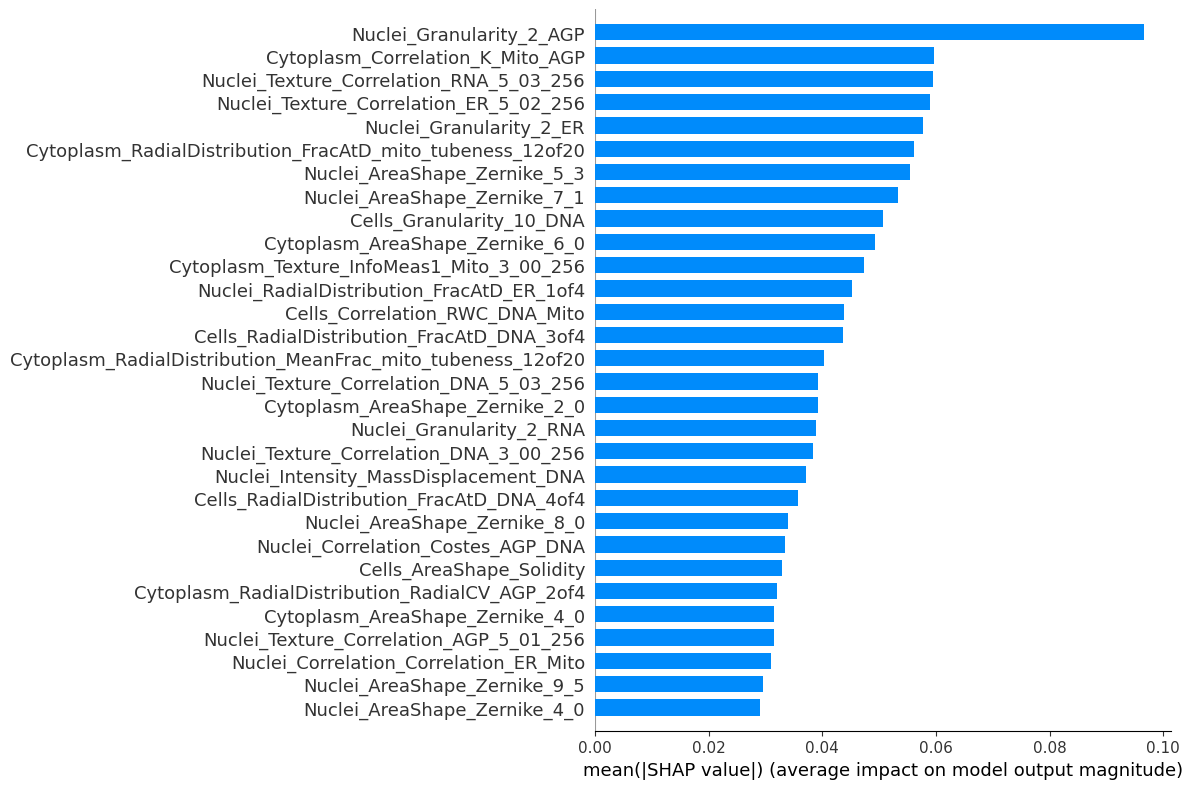

In [117]:
shap.summary_plot(
    shap_values,
    X_explain_np,
    feature_names=feature_cols,
    plot_type="bar",
    plot_size=(12,8),
    max_display=30,
    show=False
)
plt.tight_layout()
plt.show()

/tmp/ipython-input-3153281362.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


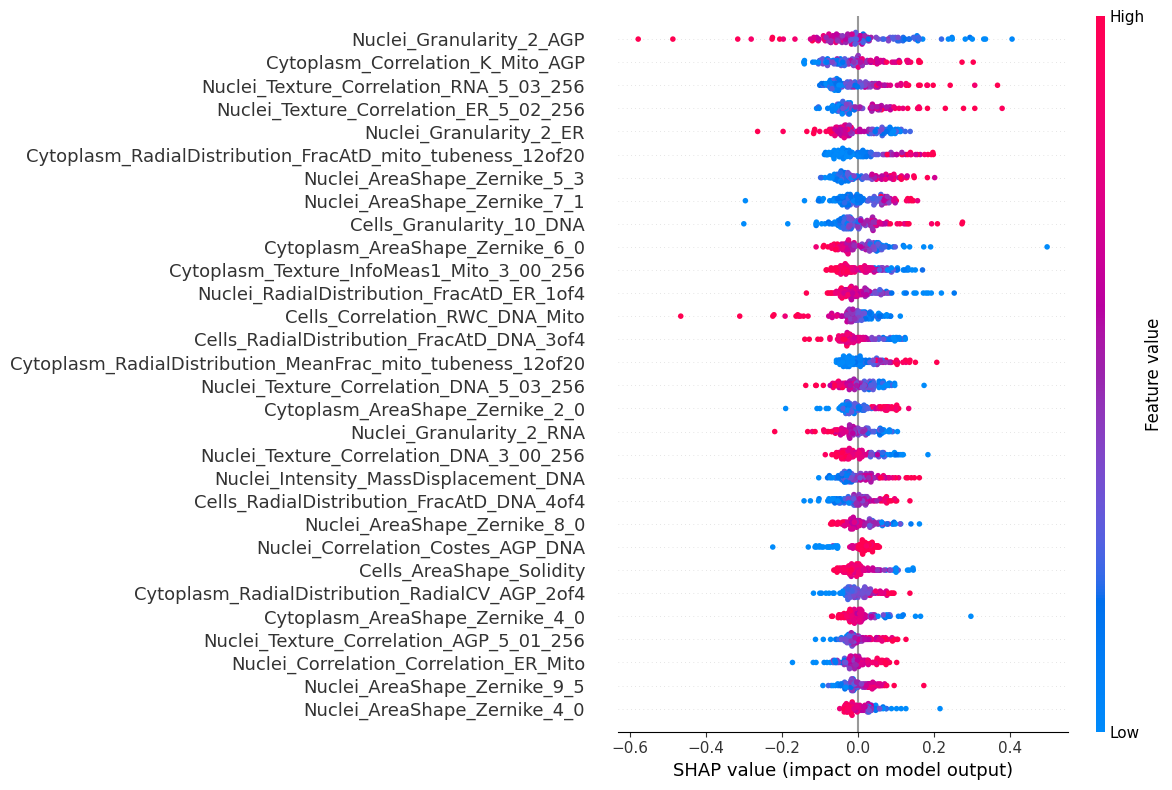

In [118]:
# beeswarm
shap.summary_plot(
    shap_values,
    X_explain_np,
    feature_names=feature_cols,
    max_display=30,
    plot_size=(12,8),
    show=False
)
plt.tight_layout()
plt.show()

Nuclei_Granularity_2_AGP


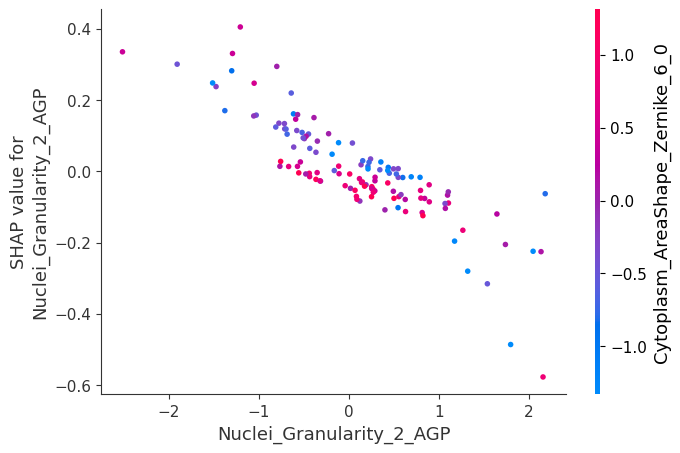

In [110]:
# Dependence plot for one top feature
top_feature = feature_cols[np.argsort(np.abs(shap_values).mean(axis=0))[-1]]
print(top_feature)
shap.dependence_plot(
    top_feature,
    shap_values,
    X_explain_np,
    feature_names=feature_cols
)

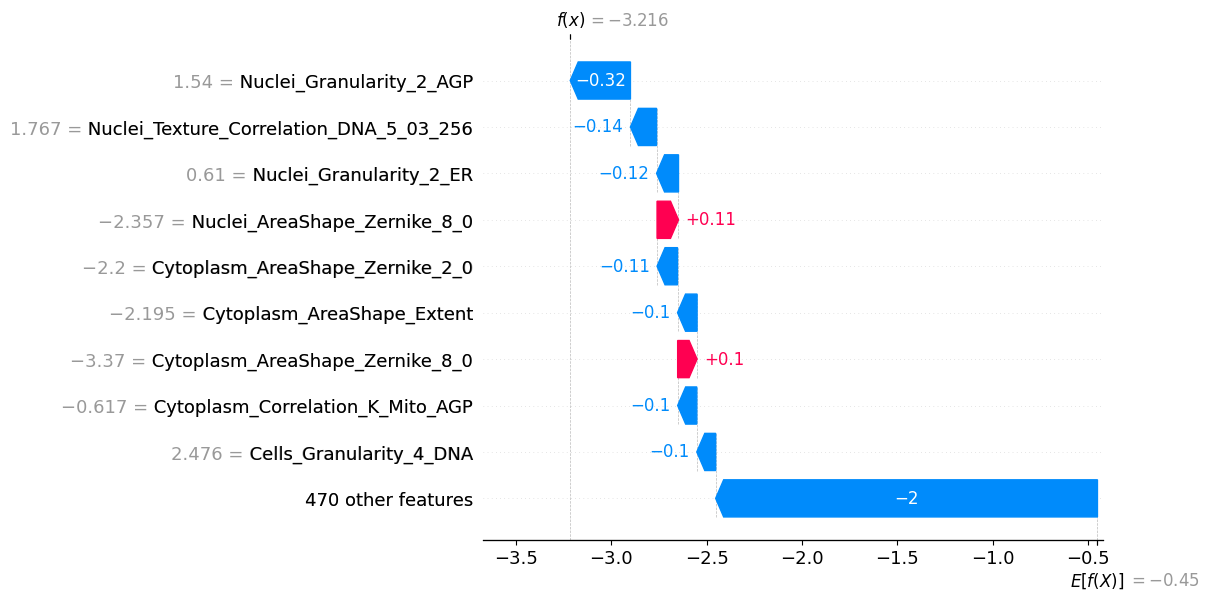

In [111]:
i = 62  # pick an index inside the explain set
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[i],
        base_values=np.mean(wrapped_model(X_bg).detach().cpu().numpy()),
        data=X_explain_np[i],
        feature_names=feature_cols
    )
)

Check cosine similarities of morphological features

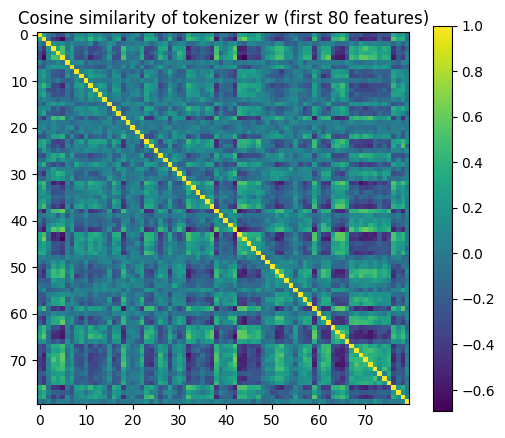

In [112]:
@torch.no_grad()
def cosine_sim_matrix(W: torch.Tensor):
    Wn = W / (W.norm(dim=1, keepdim=True) + 1e-12)
    return (Wn @ Wn.T).cpu().numpy()

W = model.tokenizer.w.detach().cpu()          # [D, d_model]
S = cosine_sim_matrix(W)                      # [D, D]

# show a small top-left chunk just as a sanity check
plt.figure(figsize=(6,5))
plt.imshow(S[:80, :80], interpolation="nearest")
plt.title("Cosine similarity of tokenizer w (first 80 features)")
plt.colorbar()
plt.show()

Inspect the top weights and their associated feature

In [113]:
w_norm = model.tokenizer.w.detach().norm(dim=1).cpu().numpy()  # [D]
top_idx = np.argsort(-w_norm)[:30]
for i in top_idx:
    print(i, feature_cols[i], w_norm[i])

341 Nuclei_AreaShape_Zernike_5_3 0.4767659
384 Nuclei_Granularity_2_AGP 0.4629672
396 Nuclei_Intensity_IntegratedIntensityEdge_DNA 0.44681957
442 Nuclei_Texture_Correlation_AGP_5_01_256 0.4419765
65 Cells_Granularity_10_DNA 0.43999705
44 Cells_Correlation_K_Mito_DNA 0.43626907
190 Cytoplasm_Correlation_K_ER_Mito 0.4337233
42 Cells_Correlation_K_DNA_Mito 0.4326107
191 Cytoplasm_Correlation_K_Mito_AGP 0.42721403
444 Nuclei_Texture_Correlation_AGP_5_03_256 0.42576313
386 Nuclei_Granularity_2_ER 0.42425588
439 Nuclei_Texture_Correlation_AGP_10_02_256 0.42311436
167 Cytoplasm_AreaShape_Zernike_6_0 0.4201044
98 Cells_RadialDistribution_FracAtD_DNA_4of4 0.4181169
457 Nuclei_Texture_Correlation_ER_5_02_256 0.4147997
360 Nuclei_Correlation_Correlation_Mito_RNA 0.4118497
32 Cells_Correlation_Correlation_DNA_Mito 0.411611
347 Nuclei_AreaShape_Zernike_8_0 0.4092884
395 Nuclei_Granularity_9_DNA 0.40528476
380 Nuclei_Granularity_11_DNA 0.4047292
329 Nuclei_AreaShape_BoundingBoxMinimum_Y 0.40408236
4